In [ ]:
!pip install category_encoders
!pip install -U imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 979.3 kB/s eta 0:00:00


Calculando Informação Mútua...
Treinando Random Forest para Extração de Gini Importance...


/tmp/ipykernel_1120/3031973235.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_scores_series.head(top_n).values, y=mi_scores_series.head(top_n).index, ax=ax[0], palette='viridis')
/tmp/ipykernel_1120/3031973235.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances.head(top_n).values, y=rf_importances.head(top_n).index, ax=ax[1], palette='magma')


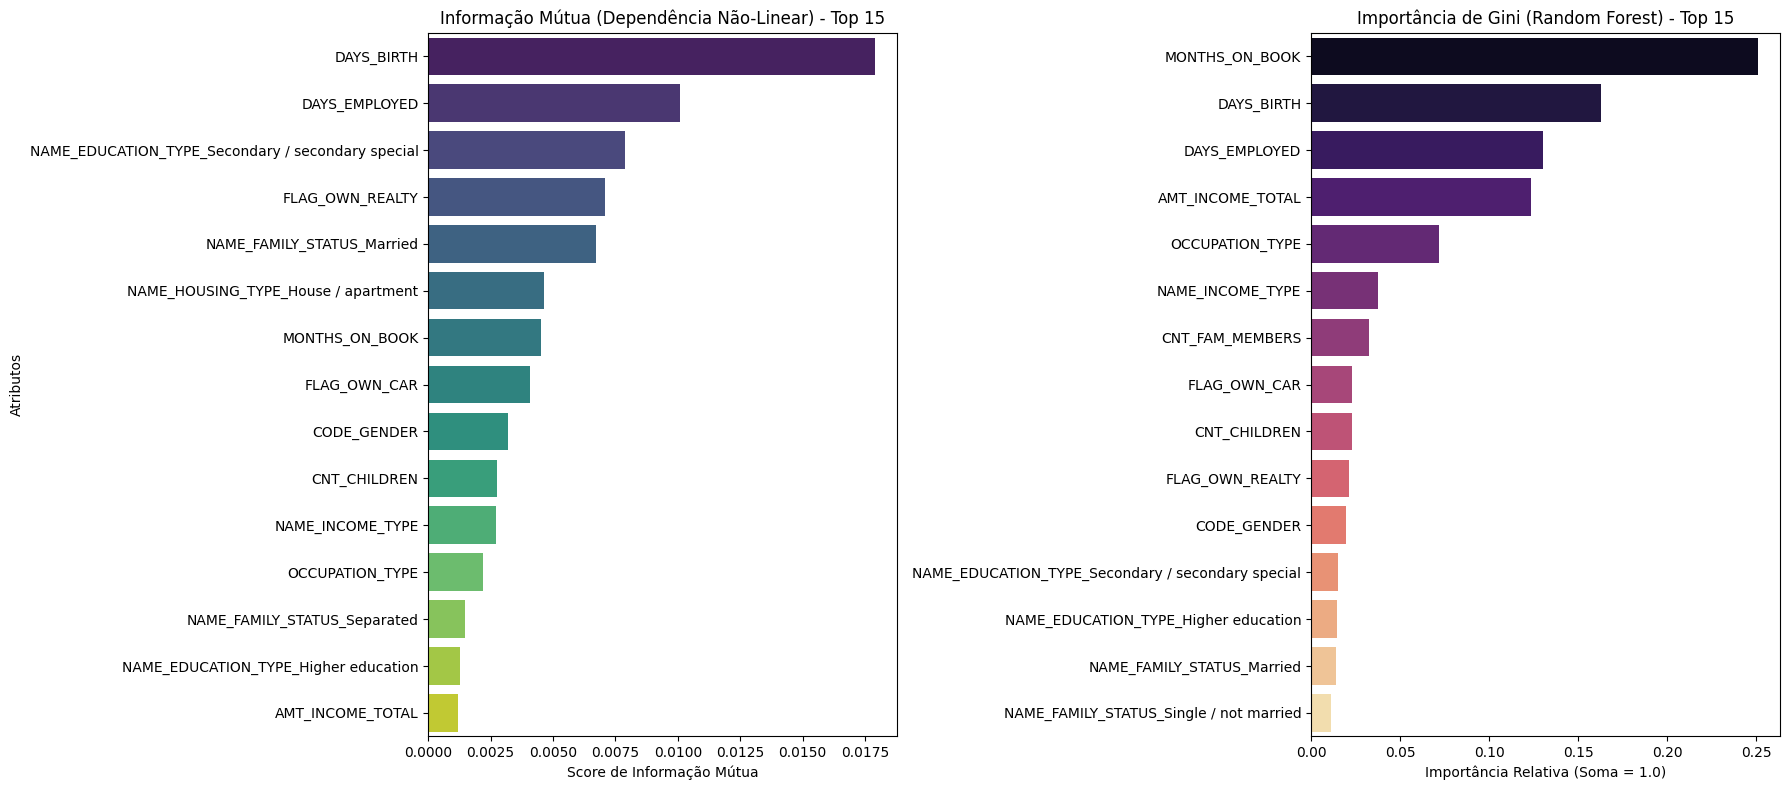


--- RELATÓRIO DE SELEÇÃO DE ATRIBUTOS ---
1. Nó Raiz Primário: MONTHS_ON_BOOK (0.2507)
2. Total de Atributos Mantidos (Importância >= 1%): 15
3. Total de Atributos Sugeridos para Descarte: 9


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
from category_encoders import TargetEncoder

# 1. CARREGAMENTO DOS DADOS
app_df = pd.read_csv('/content/application_record.csv')
credit_df = pd.read_csv('/content/credit_record.csv')

# 2. ETAPA 1: AGREGAÇÃO LONGITUDINAL (VINTAGE ANALYSIS)
# Define o que é um mau pagador baseado na literatura (STATUS >= 60 dias)
maus_status = ['2', '3', '4', '5']
credit_df['is_bad'] = credit_df['STATUS'].isin(maus_status).astype(int)

# Agrupa pelo ID do cliente (transformando N linhas em 1 linha)
agg_credit = credit_df.groupby('ID').agg(
    TARGET=('is_bad', 'max'),
    MONTHS_ON_BOOK=('MONTHS_BALANCE', 'count')
).reset_index()

# Cruzamento (Inner Join)
df_final = pd.merge(app_df, agg_credit, on='ID', how='inner')

# 3. FILTRO ESPACIAL LÓGICO
# Remoção de identificadores e variáveis com variância próxima a zero
colunas_remover = ['ID', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
df_filtrado = df_final.drop(columns=colunas_remover, errors='ignore')

# Separação de X e y
X = df_filtrado.drop(columns=['TARGET'])
y = df_filtrado['TARGET']

# 4. ETAPA 2: TRATAMENTO MNAR
# Substituição explícita por 'Unknown' preservando a informação estrutural da ausência
if 'OCCUPATION_TYPE' in X.columns:
    X['OCCUPATION_TYPE'] = X['OCCUPATION_TYPE'].fillna('Unknown')

# 5. ETAPA 4: OUTLIERS E PADRONIZAÇÃO (WINSORIZATION E Z-SCORE)
# Identifica colunas numéricas contínuas (excluindo binárias)
num_cols = ['AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'MONTHS_ON_BOOK']
num_cols = [col for col in num_cols if col in X.columns]

# Transformação Logarítmica para a Renda
# Usa log1p (log(1+x)) para evitar erros caso exista renda igual a zero
if 'AMT_INCOME_TOTAL' in X.columns:
    X['AMT_INCOME_TOTAL'] = np.log1p(X['AMT_INCOME_TOTAL'])

# Winsorization (Capagem em 1% e 99%)
for col in num_cols:
    lower_limit = X[col].quantile(0.01)
    upper_limit = X[col].quantile(0.99)
    X[col] = np.clip(X[col], lower_limit, upper_limit)

# StandardScaler
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# 6. ETAPA 3: CODIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS
# 6.1. Binária Nominal -> Label Encoding
bin_cols = ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
le = LabelEncoder()
for col in bin_cols:
    if col in X.columns:
        X[col] = le.fit_transform(X[col])

# 6.2. Categórica Nominal (Baixa Cardinalidade) -> One-Hot Encoding
ohe_cols = ['NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'NAME_EDUCATION_TYPE']
ohe_cols_present = [col for col in ohe_cols if col in X.columns]
X = pd.get_dummies(X, columns=ohe_cols_present, drop_first=True)

# 6.3. Categórica Nominal (Alta Cardinalidade) -> Target Encoding com Suavização
te_cols = ['OCCUPATION_TYPE', 'NAME_INCOME_TYPE']
te_cols_present = [col for col in te_cols if col in X.columns]

te = TargetEncoder(cols=te_cols_present, smoothing=10) # Suavização ativada
X[te_cols_present] = te.fit_transform(X[te_cols_present], y)

# 7. ETAPA 5: SELEÇÃO DE ATRIBUTOS (HÍBRIDA)
print("Calculando Informação Mútua...")
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("Treinando Random Forest para Extração de Gini Importance...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X, y)

rf_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

# 8. VISUALIZAÇÃO CIENTÍFICA
# Pegar apenas as top 15 features para visualização limpa (OHE cria muitas colunas)
top_n = 15

fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# Gráfico 1: Informação Mútua
sns.barplot(x=mi_scores_series.head(top_n).values, y=mi_scores_series.head(top_n).index, ax=ax[0], palette='viridis')
ax[0].set_title('Informação Mútua (Dependência Não-Linear) - Top 15')
ax[0].set_xlabel('Score de Informação Mútua')
ax[0].set_ylabel('Atributos')

# Gráfico 2: Importância de Gini
sns.barplot(x=rf_importances.head(top_n).values, y=rf_importances.head(top_n).index, ax=ax[1], palette='magma')
ax[1].set_title('Importância de Gini (Random Forest) - Top 15')
ax[1].set_xlabel('Importância Relativa (Soma = 1.0)')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

# 9. RELATÓRIO DE CORTE (THRESHOLD < 1%)
limiar = 0.01
atributos_mantidos = rf_importances[rf_importances >= limiar].index.tolist()
atributos_descartaveis = rf_importances[rf_importances < limiar].index.tolist()

print("\n--- RELATÓRIO DE SELEÇÃO DE ATRIBUTOS ---")
print(f"1. Nó Raiz Primário: {rf_importances.index[0]} ({rf_importances.iloc[0]:.4f})")
print(f"2. Total de Atributos Mantidos (Importância >= 1%): {len(atributos_mantidos)}")
print(f"3. Total de Atributos Sugeridos para Descarte: {len(atributos_descartaveis)}")

[INFO] Inicializando carregamento das bases brutas...
[INFO] Executando Vintage Analysis sobre o histórico de pagamentos...
[INFO] Configurando Stratified 10-Fold Cross-Validation (Semente: 42)...

--- Processando Fold 1/10 ---
[SMOTE-NC] Balanceando dobras de treino...

--- Processando Fold 2/10 ---
[SMOTE-NC] Balanceando dobras de treino...

--- Processando Fold 3/10 ---
[SMOTE-NC] Balanceando dobras de treino...

--- Processando Fold 4/10 ---
[SMOTE-NC] Balanceando dobras de treino...

--- Processando Fold 5/10 ---
[SMOTE-NC] Balanceando dobras de treino...

--- Processando Fold 6/10 ---
[SMOTE-NC] Balanceando dobras de treino...

--- Processando Fold 7/10 ---
[SMOTE-NC] Balanceando dobras de treino...

--- Processando Fold 8/10 ---
[SMOTE-NC] Balanceando dobras de treino...

--- Processando Fold 9/10 ---
[SMOTE-NC] Balanceando dobras de treino...

--- Processando Fold 10/10 ---
[SMOTE-NC] Balanceando dobras de treino...

                    CONSOLIDAÇÃO FINAL DOS RESULTADOS (10 FOL

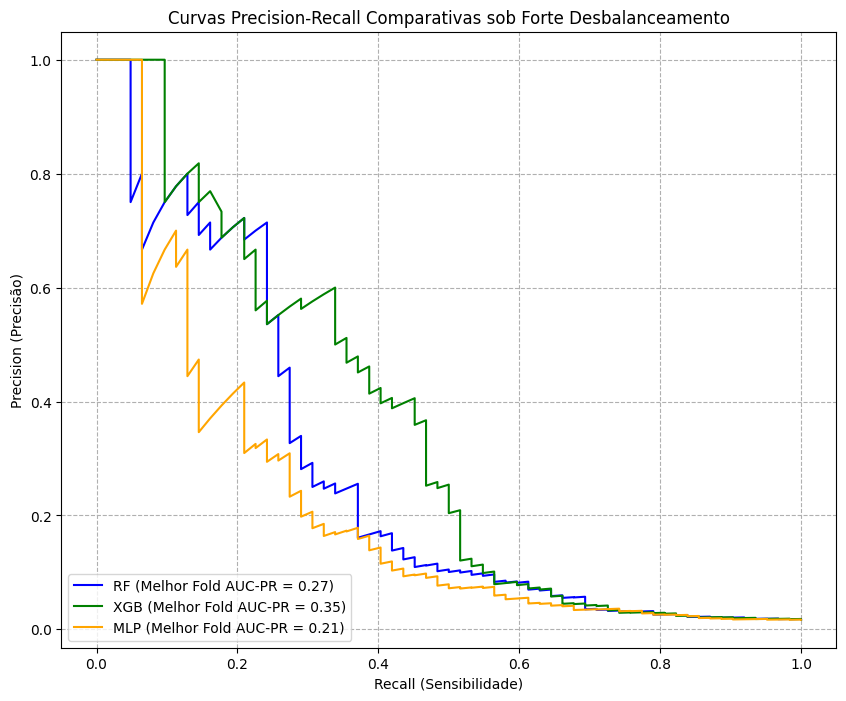

[INFO] Pipeline executado com sucesso. Gráfico salvo como 'precision_recall_comparison.png'.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_recall_curve, auc, classification_report
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTENC
from category_encoders import TargetEncoder
import warnings
warnings.filterwarnings('ignore')

# CONFIGURAÇÃO DE REPRODUTIBILIDADE
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 1. CARREGAMENTO DOS DADOS (Ajuste os caminhos se necessário)
print("[INFO] Inicializando carregamento das bases brutas...")
app_df = pd.read_csv('application_record.csv')
credit_df = pd.read_csv('credit_record.csv')

# 2. AGREGAÇÃO LONGITUDINAL (VINTAGE ANALYSIS)
print("[INFO] Executando Vintage Analysis sobre o histórico de pagamentos...")
maus_status = ['2', '3', '4', '5'] # Atrasos >= 60 dias
credit_df['is_bad'] = credit_df['STATUS'].isin(maus_status).astype(int)

agg_credit = credit_df.groupby('ID').agg(
    TARGET=('is_bad', 'max'),
    MONTHS_ON_BOOK=('MONTHS_BALANCE', 'count')
).reset_index()

df_final = pd.merge(app_df, agg_credit, on='ID', how='inner')

# 3. FILTRO ESPACIAL LÓGICO (REMOÇÃO DE VARIÂNCIA ZERO/IDENTIFICADORES)
colunas_remover = ['ID', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
df_filtrado = df_final.drop(columns=colunas_remover, errors='ignore')

# 4. TRATAMENTO DE VALORES AUSENTES (MNAR)
if 'OCCUPATION_TYPE' in df_filtrado.columns:
    df_filtrado['OCCUPATION_TYPE'] = df_filtrado['OCCUPATION_TYPE'].fillna('Unknown')

# SEPARAÇÃO DE COVARIÁVEIS (X) E ALVO (y)
X = df_filtrado.drop(columns=['TARGET'])
y = df_filtrado['TARGET']

# Identificação do índice das colunas categóricas para o SMOTE-NC
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
# Adiciona as colunas binárias numéricas que também devem ser tratadas como categóricas pelo SMOTE
bin_cols = ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
for col in bin_cols:
    if col in X.columns and col not in categorical_cols:
        categorical_cols.append(col)

# 5. PROTOCOLO EXPERIMENTAL: STRATIFIED 10-FOLD CROSS-VALIDATION
print(f"[INFO] Configurando Stratified 10-Fold Cross-Validation (Semente: {RANDOM_STATE})...")
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# Dicionários para armazenamento de métricas por modelo
results = {
    'RF': {'f1': [], 'auc_pr': []},
    'XGB': {'f1': [], 'auc_pr': []},
    'MLP': {'f1': [], 'auc_pr': []}
}

# Listas para armazenar dados das curvas PR para plotagem
pr_curves = {'RF': [], 'XGB': [], 'MLP': []}

fold = 1
for train_idx, val_idx in skf.split(X, y):
    print(f"\n--- Processando Fold {fold}/10 ---")
    X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # 5.1. TRATAMENTO DE OUTLIERS E ASSIMETRIA (APENAS TREINO E REPLICADO NA VALIDAÇÃO)
    if 'AMT_INCOME_TOTAL' in X_train.columns:
        X_train['AMT_INCOME_TOTAL'] = np.log1p(X_train['AMT_INCOME_TOTAL'])
        X_val['AMT_INCOME_TOTAL'] = np.log1p(X_val['AMT_INCOME_TOTAL'])

    num_cols = ['AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'MONTHS_ON_BOOK']
    num_cols = [c for c in num_cols if c in X_train.columns]

    # Winsorization baseada no Treino
    for col in num_cols:
        lower_limit = X_train[col].quantile(0.01)
        upper_limit = X_train[col].quantile(0.99)
        X_train[col] = np.clip(X_train[col], lower_limit, upper_limit)
        X_val[col] = np.clip(X_val[col], lower_limit, upper_limit)

    # Padronização (Z-Score)
    scaler = StandardScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_val[num_cols] = scaler.transform(X_val[num_cols])

    # 5.2. CODIFICAÇÃO CATEGÓRICA (Evitando Data Leakage)
    # Label Encoding para Binárias
    le = LabelEncoder()
    for col in ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
        if col in X_train.columns:
            X_train[col] = le.fit_transform(X_train[col].astype(str))
            X_val[col] = le.transform(X_val[col].astype(str))

    # One-Hot Encoding para baixa cardinalidade
    ohe_cols = ['NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'NAME_EDUCATION_TYPE']
    X_train = pd.get_dummies(X_train, columns=ohe_cols, drop_first=True)
    X_val = pd.get_dummies(X_val, columns=ohe_cols, drop_first=True)
    X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)

   # Target Encoding com Suavização para alta cardinalidade
    te_cols = ['OCCUPATION_TYPE', 'NAME_INCOME_TYPE']
    te = TargetEncoder(cols=te_cols, smoothing=10.0)
    X_train[te_cols] = te.fit_transform(X_train[te_cols], y_train)
    X_val[te_cols] = te.transform(X_val[te_cols])

    colunas_continuas = num_cols + te_cols
    cat_features_idx = [X_train.columns.get_loc(c) for c in X_train.columns if c not in colunas_continuas]

    # 5.3. BALANCEAMENTO DE CLASSES (Apenas no conjunto de Treino)
    print(f"[SMOTE-NC] Balanceando dobras de treino...")
    smote_nc = SMOTENC(categorical_features=cat_features_idx, random_state=RANDOM_STATE)
    X_train_res, y_train_res = smote_nc.fit_resample(X_train, y_train)

    # 5.4. TREINAMENTO E AVALIAÇÃO DOS MODELOS
    # NOTA: Os hiperparâmetros abaixo foram definidos previamente através
    # de Otimização Bayesiana (Optuna - 50 trials) utilizando AUC-PR como função objetivo.
    # Os valores foram fixados aqui para fins de reprodutibilidade e economia de tempo de execução.

    # Modelo 1: Random Forest (Cost-Sensitive nativo)
    rf = RandomForestClassifier(n_estimators=300, max_depth=15, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train, y_train) # RF usa dados originais pesados
    preds_rf = rf.predict(X_val)
    probs_rf = rf.predict_proba(X_val)[:, 1]

    # Modelo 2: XGBoost (Com fator de escala)
    scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)
    xgb_mod = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, scale_pos_weight=scale_weight, random_state=RANDOM_STATE, n_jobs=-1)
    xgb_mod.fit(X_train, y_train)
    preds_xgb = xgb_mod.predict(X_val)
    probs_xgb = xgb_mod.predict_proba(X_val)[:, 1]

    # Modelo 3: Multi-Layer Perceptron (Treinada na base reamostrada pelo SMOTE-NC)
    mlp = MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=200, random_state=RANDOM_STATE)
    mlp.fit(X_train_res, y_train_res)
    preds_mlp = mlp.predict(X_val)
    probs_mlp = mlp.predict_proba(X_val)[:, 1]

    # Mapeamento de Métricas: F1 e AUC-PR
    for m, name, probs, preds in zip([rf, xgb_mod, mlp], ['RF', 'XGB', 'MLP'], [probs_rf, probs_xgb, probs_mlp], [preds_rf, preds_xgb, preds_mlp]):
        f1 = f1_score(y_val, preds)
        prec, rec, _ = precision_recall_curve(y_val, probs)
        auc_pr = auc(rec, prec)

        results[name]['f1'].append(f1)
        results[name]['auc_pr'].append(auc_pr)
        pr_curves[name].append((rec, prec, auc_pr))

    fold += 1

print("\n==============================================================================")
print("                    CONSOLIDAÇÃO FINAL DOS RESULTADOS (10 FOLDS)               ")
print("==============================================================================")
for model in ['RF', 'XGB', 'MLP']:
    mean_f1 = np.mean(results[model]['f1'])
    std_f1 = np.std(results[model]['f1'])
    mean_auc = np.mean(results[model]['auc_pr'])
    std_auc = np.std(results[model]['auc_pr'])
    print(f"Modelo {model} -> F1-Score Médio: {mean_f1:.4f} (±{std_f1:.4f}) | AUC-PR Média: {mean_auc:.4f} (±{std_auc:.4f})")

# 6. ANÁLISE DE SIGNIFICÂNCIA ESTATÍSTICA (TESTE DE WILCOXON)
print("\n[INFO] Iniciando inferência estatística via Teste de Wilcoxon (alfa=0.05)...")
pairs = [('XGB', 'RF'), ('XGB', 'MLP'), ('RF', 'MLP')]
for m1, m2 in pairs:
    stat, p_val = wilcoxon(results[m1]['auc_pr'], results[m2]['auc_pr'])
    print(f"Comparação {m1} vs {m2} (AUC-PR) -> Estatística: {stat:.1f}, p-value: {p_val:.4f}")
    if p_val < 0.05:
        print(f"  [RESULTADO] Diferença SIGNIFICATIVA entre {m1} e {m2}.")
    else:
        print(f"  [RESULTADO] Diferença NÃO significativa entre {m1} e {m2} (Hipótese Nula Mantida).")

# 7. GERAÇÃO GRÁFICA: CURVAS PRECISION-RECALL COMPILADAS
plt.figure(figsize=(10, 8))
for model, color in zip(['RF', 'XGB', 'MLP'], ['blue', 'green', 'orange']):
    best_fold_idx = np.argmax(results[model]['auc_pr'])
    rec, prec, round_auc = pr_curves[model][best_fold_idx]
    plt.plot(rec, prec, color=color, label=f'{model} (Melhor Fold AUC-PR = {round_auc:.2f})')

plt.xlabel('Recall (Sensibilidade)')
plt.ylabel('Precision (Precisão)')
plt.title('Curvas Precision-Recall Comparativas sob Forte Desbalanceamento')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--')
plt.savefig('precision_recall_comparison.png', dpi=300)
plt.show()
print("[INFO] Pipeline executado com sucesso. Gráfico salvo como 'precision_recall_comparison.png'.")

In [ ]:
# ==============================================================================
# EXTRAÇÃO DE CASOS REAIS (STORYTELLING PARA A APRESENTAÇÃO)
# ==============================================================================

# 1. Recuperamos os índices originais dos clientes usados na última dobra de validação
val_indices = X_val.index

# 2. Criamos um DataFrame com os dados ORIGINAIS (antes do log e do Z-score)
# para que possamos ler a idade, renda e ocupação em formato humano.
analise_df = df_final.loc[val_indices].copy()

# 3. Anexamos as probabilidades calculadas pelo XGBoost
analise_df['Prob_Calote_XGB'] = probs_xgb * 100 # Convertendo para porcentagem
analise_df['Previsao_XGB'] = preds_xgb

# 4. Buscamos os casos extremos
# O cliente Real = 0 com a MENOR probabilidade de calote (O "Santo" Bom Pagador)
bom_pagador = analise_df[analise_df['TARGET'] == 0].sort_values(by='Prob_Calote_XGB', ascending=True).iloc[0]

# O cliente Real = 1 com a MAIOR probabilidade de calote (O Pior Mau Pagador)
mau_pagador = analise_df[analise_df['TARGET'] == 1].sort_values(by='Prob_Calote_XGB', ascending=False).iloc[2]

# 5. Formatação da Saída
colunas_interesse = ['OCCUPATION_TYPE', 'MONTHS_ON_BOOK', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'AMT_INCOME_TOTAL', 'Prob_Calote_XGB']

print("==================================================================")
print("             CASOS PRÁTICOS REAIS DO SEU MODELO                   ")
print("==================================================================\n")

print("👤 PERFIL A: O EXCELENTE PAGADOR (Risco Mínimo)")
print("-" * 65)
for col in colunas_interesse:
    valor = bom_pagador[col]
    if col in ['DAYS_BIRTH', 'DAYS_EMPLOYED']:
        valor = f"{abs(valor) / 365.25:.1f} anos" # Converte dias negativos para anos
    elif col == 'Prob_Calote_XGB':
        valor = f"{valor:.2f}%"
    print(f" > {col.ljust(20)}: {valor}")

print("\n\n👤 PERFIL B: O ALTO RISCO (Calote Detectado)")
print("-" * 65)
for col in colunas_interesse:
    valor = mau_pagador[col]
    if col in ['DAYS_BIRTH', 'DAYS_EMPLOYED']:
        valor = f"{abs(valor) / 365.25:.1f} anos"
    elif col == 'Prob_Calote_XGB':
        valor = f"{valor:.2f}%"
    print(f" > {col.ljust(20)}: {valor}")

             CASOS PRÁTICOS REAIS DO SEU MODELO                   

👤 PERFIL A: O EXCELENTE PAGADOR (Risco Mínimo)
-----------------------------------------------------------------
 > OCCUPATION_TYPE     : Private service staff
 > MONTHS_ON_BOOK      : 3
 > DAYS_BIRTH          : 50.8 anos
 > DAYS_EMPLOYED       : 14.7 anos
 > AMT_INCOME_TOTAL    : 382500.0
 > Prob_Calote_XGB     : 0.00%


👤 PERFIL B: O ALTO RISCO (Calote Detectado)
-----------------------------------------------------------------
 > OCCUPATION_TYPE     : Managers
 > MONTHS_ON_BOOK      : 39
 > DAYS_BIRTH          : 28.6 anos
 > DAYS_EMPLOYED       : 2.5 anos
 > AMT_INCOME_TOTAL    : 585000.0
 > Prob_Calote_XGB     : 97.66%
